# E-Commerce Sales Analysis – Python

## Project Objective
Analyze sales performance, customer distribution, and monthly revenue trends.

## Data Cleaning
## Feature Engineering
## Revenue Analysis
## Customer Concentration
## Monthly Growth Analysis
## Business Insights

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os
os.listdir()

In [ ]:
df = pd.read_csv("supermarket database.csv", encoding="latin1")
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [41]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"], dayfirst=True)
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"], dayfirst=True)

In [ ]:
df.dtypes

In [ ]:
df["Shipping_Days"] = (df["Ship_Date"] - df["Order_Date"]).dt.days
df.head()

In [ ]:
df["Shipping_Days"].describe()

In [ ]:
df[df["Shipping_Days"] < 0]

In [ ]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

In [ ]:
region_percentage = (region_sales / region_sales.sum()) * 100
region_percentage

In [ ]:
region_orders = df.groupby("Region")["Order_ID"].nunique()
region_orders

In [ ]:
region_avg = df.groupby("Region")["Sales"].mean()
region_avg

In [ ]:
region_aov = df.groupby("Region")["Sales"].mean()
region_aov

In [42]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

In [43]:
sub_category_sales = df.groupby("Sub_Category")["Sales"].sum().sort_values(ascending=False)
sub_category_sales.head(10)

Sub_Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

In [ ]:
plt.figure(figsize=(10,6))
sub_category_sales.head(10).plot(kind="bar")
plt.title("Top 10 Sub-Categories by Sales")
plt.ylabel("Total Sales")
plt.show()

In [ ]:
df.isnull().sum()

In [44]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

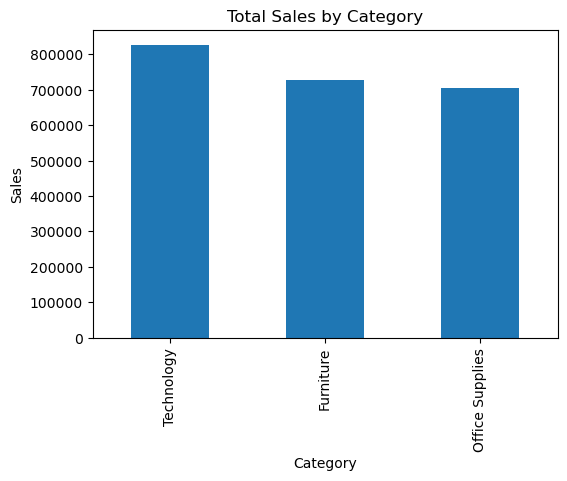

In [45]:
category_sales.plot(kind="bar", figsize=(6,4))
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.show()

In [ ]:
df["Month"] = df["Order_Date"].dt.to_period("M")

In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales.head()

In [ ]:
monthly_sales.plot(figsize=(8,4))
plt.title("Monthly Sales Trend")
plt.show()

In [ ]:
customer_sales = df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False)
customer_sales.head(10)

In [ ]:
top_10_share = customer_sales.head(10).sum() / customer_sales.sum() * 100
top_10_share

In [ ]:
df.groupby("Region")["Shipping_Days"].mean().sort_values()

In [ ]:
df.groupby("Region").agg({
    "Sales": "sum",
    "Shipping_Days": "mean"
})

In [ ]:
monthly_sales = df.groupby("Month")["Sales"].sum().sort_index()

monthly_growth = monthly_sales.pct_change() * 100

monthly_growth.head()

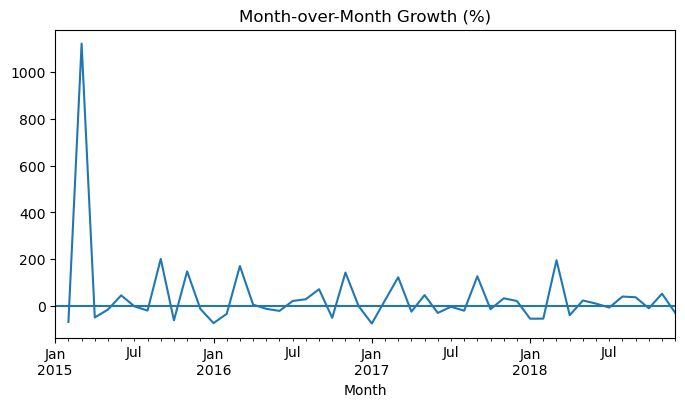

In [46]:
monthly_growth.plot(figsize=(8,4))
plt.title("Month-over-Month Growth (%)")
plt.axhline(0)
plt.show()

In [47]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

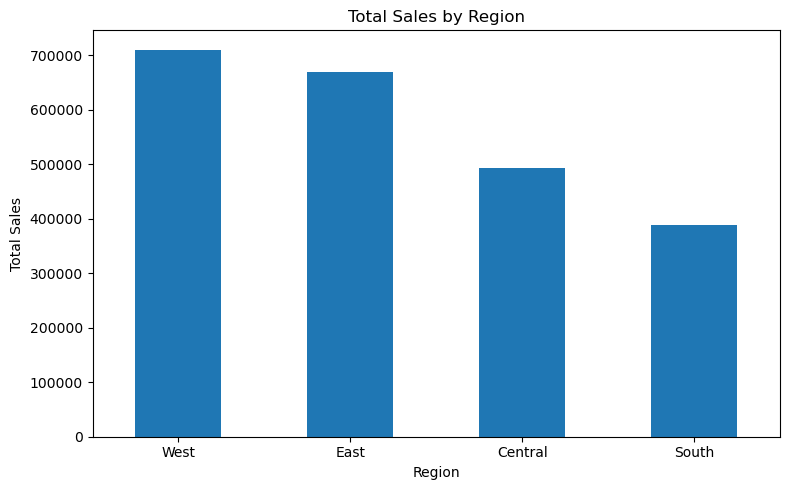

In [48]:
plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("region_sales.png")
plt.show()